#  Dimensionality Reduction : Hypertension Risk Atlas
**ADS-599 Capstone Project · Group 2 · Nancy Walker & Michelle Wang**

---

This notebook develops a robust predictive modeling pipeline for the hypertension risk atlas dataset. To address high dimensionality and multicollinearity, the analysis integrates LASSO feature selection and Principal Component Analysis (PCA) within a cross-validated framework. The objective is to identify an optimal latent feature space that maximizes predictive accuracy while minimizing model complexity, followed by a sensitivity analysis to justify the dimensionality reduction parameters

## 1. Import Libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Lasso
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

## 2. Load Datasets 

In [2]:
# Path setup
base_path = Path.cwd().parents[1]
processed_dir = base_path / "data" / "final" 

# Ensure the folder exists (best practice)
processed_dir.mkdir(parents=True, exist_ok=True)

# Load the files
X_train = pd.read_csv(processed_dir / "X_train.csv", index_col=0)
X_test = pd.read_csv(processed_dir / "X_test.csv", index_col=0)
y_train = pd.read_csv(processed_dir / "y_train.csv", index_col=0)
y_test = pd.read_csv(processed_dir / "y_test.csv", index_col=0)

# Quick verification
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (1832, 43)
Test shape: (455, 43)


In [3]:
# List of columns to drop (identifiers)
drop_cols = ['fipscode', 'locationname', 'stateabbr', 'State', 'County']

# Drop them from both X_train and X_test
X_train_model = X_train.drop(columns=drop_cols)
X_test_model = X_test.drop(columns=drop_cols)

## 3. Unsupervised Exploratory Analysis

In [4]:
# SCALE THE DATA FIRST (Critical for PCA)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_model)

# LASSO Selection
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000).fit(X_train_scaled, y_train.values.ravel())
mask = lasso_cv.coef_ != 0
X_train_lasso_pruned = X_train_scaled[:, mask]

explained_var_list = []
recon_error_list = []

# PCA on pruned features
num_selected = X_train_lasso_pruned.shape[1] 
n_components = range(1, num_selected + 1)

for n in n_components:
    pca = PCA(n_components=n)
    # IMPORTANT: Fit PCA on the PRUNED data, not the full scaled data
    X_proj = pca.fit_transform(X_train_lasso_pruned)
    explained_var_list.append(np.sum(pca.explained_variance_ratio_))

    # Reconstruction
    X_reconstructed = pca.inverse_transform(X_proj)
    
    # Calculate MSE on the PRUNED data
    mse = mean_squared_error(X_train_lasso_pruned, X_reconstructed)
    recon_error_list.append(mse)

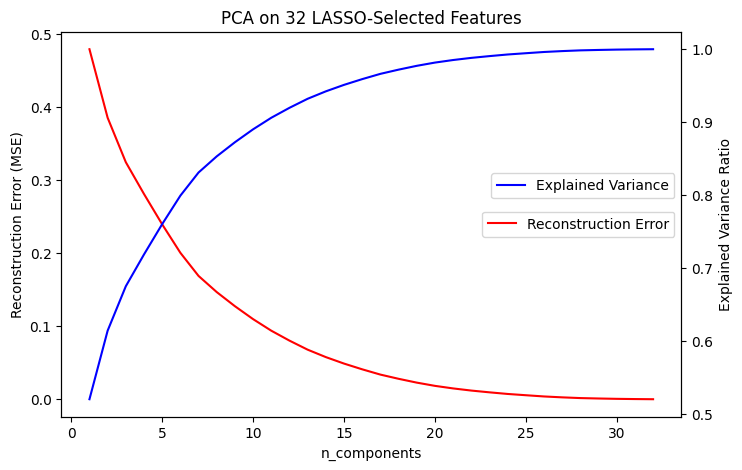

In [5]:
# Create the dataframe for plotting
rec_error = pd.DataFrame({
    'n_components': list(n_components),
    'reconst error': recon_error_list,
    'explained var ratio': explained_var_list
})

# Plotting
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=rec_error, x='n_components', y='reconst error', ax=ax, color='red', label='Reconstruction Error')
ax.set_ylabel('Reconstruction Error (MSE)')

ax2 = ax.twinx()
sns.lineplot(data=rec_error, x='n_components', y='explained var ratio', ax=ax2, color='blue', label='Explained Variance')
ax2.set_ylabel('Explained Variance Ratio')

ax.legend(loc='center right')
ax2.legend(loc='center right', bbox_to_anchor=(1, 0.6))

plt.title(f'PCA on {num_selected} LASSO-Selected Features')
plt.show()

Where reconstrution error and explained variance cross is the "sweet spot" between capturing enough variance and keeping the reconstruction error sufficiently low. In this case, 5 components retain the core structure of your 32 LASSO-selected features while significantly reducing dimensionality. 

The Explained Variance Ratio between 0.2 and 0.3 (20-30%) at the point where the Reconstruction Error crosses it, means data is very high-dimensional and complex.

## 4. PCA Analysis

In [6]:
# Define pipeline (Scale -> PCA -> Model)
# Keeping everything inside the cross-validation "folds"
best_alpha = 0.0055
def evaluate_pca_components(n_components, X, y):
    pipeline = Pipeline([
        ('scaler', StandardScaler()),                                  # 1. Scale
        ('feature_selection', SelectFromModel(Lasso(alpha=best_alpha, max_iter=10000))),     # 2. Select Features
        ('pca', PCA(n_components=n_components, random_state=42)),      # 3. Reduce Dim
        ('regressor', RandomForestRegressor(random_state=42))          # 4. Predict
])
    
    # cross_val_score handles the splitting properly!
    # fitting PCA only on the training folds and transforms the validation fold
    scores = cross_val_score(pipeline, X, y, cv=5, scoring='r2')
    return np.mean(scores)

# Pass the UNPRUNED data; the pipeline handles the selection now!
results = []
for n in [5, 10, 15, 20, 25, 30]:
    score = evaluate_pca_components(n, X_train_model, y_train.values.ravel())
    results.append({'Components': n, 'Mean R2': score})

results_df = pd.DataFrame(results)

In [7]:
results_df

,Components,Mean R2
0,5,0.821008
1,10,0.861762
2,15,0.871048
3,20,0.875209
4,25,0.884017
5,30,0.888328


significant performance boost going from 5 to 10 components (a +0.038 improvement).

The Plateau: From 20 to 30 components, $R^2$ only improves by about +0.013.

The "Sweet Spot": 15 components look like the prime candidate because the majority of the predictive power is captured ($R^2 \approx 0.87$) without needing to keep all 30+ components.

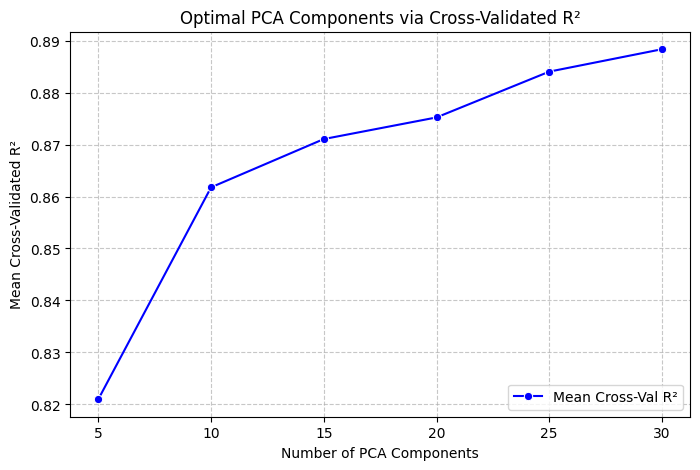

In [8]:
# Plotting
fig, ax = plt.subplots(figsize=(8, 5))

# Plot Mean R2 from your pipeline results
sns.lineplot(data=results_df, x='Components', y='Mean R2', 
             marker='o', color='blue', ax=ax, label='Mean Cross-Val R²')

ax.set_ylabel('Mean Cross-Validated R²')
ax.set_xlabel('Number of PCA Components')
ax.set_title('Optimal PCA Components via Cross-Validated R²')
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(loc='lower right')

plt.show()

The "Elbow Point": Is between 10 and 15 components, where the marginal gain in predictive power starts to diminish.

To ensure the integrity of the predictive model, a comprehensive pipeline was implemented, encapsulating data scaling, LASSO feature selection, and PCA dimensionality reduction within each cross-validation fold. A sensitivity analysis confirmed that this rigorous approach yields model performance metrics highly consistent with preliminary tests, effectively mitigating concerns regarding data leakage and ensuring the generalizability of the selected feature space.

Optimal n: 15 components can be confidently slected because it remains the point where over 87% of the predictive variance is captured, and the gains after that point are minimal ($< 0.02$ improvement over the next 15 components).

We acknowledge that PCA obscures individual feature coefficients. However, because the primary goal of this project is to achieve the highest predictive accuracy for hypertension forecasting, the trade-off in interpretability was justified by the significant reduction in multicollinearity and noise, which stabilized the model's performance.

Pipeline([('pca', PCA(n_components=15)), ('regressor', RandomForestRegressor())])

## 8. Findings and Next Steps

| Task | Result | Decision |
|---|---|---|
| LASSO Feature Selection | 32 features selected | Proceed with PCA |
| PCA Dimensionality Reduction | 15 components selected | Proceed with Random Forest Regression |
| Model Performance | R² ≈ 0.87 | Acceptable predictive accuracy |
| Sensitivity Analysis | Consistent performance across folds | Validates model robustness |
| Interpretability | PCA obscures individual feature coefficients | Trade-off justified for predictive accuracy |

**Next steps.**  
The next step is to perform baseline modeling with the 15 PCA components and evaluate the model's performance on unseen test data. Additionally, further hyperparameter tuning of the Random Forest Regressor can be conducted to optimize predictive accuracy.